In [2]:
import numpy as np
import pandas as pd

In [ ]:
fec = pd.read_csv('../datasets/fec/P00000001-ALL.csv', low_memory=False)

In [5]:
fec.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001731 entries, 0 to 1001730
Data columns (total 16 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   cmte_id            1001731 non-null  object 
 1   cand_id            1001731 non-null  object 
 2   cand_nm            1001731 non-null  object 
 3   contbr_nm          1001731 non-null  object 
 4   contbr_city        1001712 non-null  object 
 5   contbr_st          1001727 non-null  object 
 6   contbr_zip         1001620 non-null  object 
 7   contbr_employer    988002 non-null   object 
 8   contbr_occupation  993301 non-null   object 
 9   contb_receipt_amt  1001731 non-null  float64
 10  contb_receipt_dt   1001731 non-null  object 
 11  receipt_desc       14166 non-null    object 
 12  memo_cd            92482 non-null    object 
 13  memo_text          97770 non-null    object 
 14  form_tp            1001731 non-null  object 
 15  file_num           1001731 non-n

In [6]:
fec.iloc[123456]

cmte_id                             C00431445
cand_id                             P80003338
cand_nm                         Obama, Barack
contbr_nm                         ELLMAN, IRA
contbr_city                             TEMPE
contbr_st                                  AZ
contbr_zip                          852816719
contbr_employer      ARIZONA STATE UNIVERSITY
contbr_occupation                   PROFESSOR
contb_receipt_amt                        50.0
contb_receipt_dt                    01-DEC-11
receipt_desc                              NaN
memo_cd                                   NaN
memo_text                                 NaN
form_tp                                 SA17A
file_num                               772372
Name: 123456, dtype: object

In [7]:
# all the unique candidates
unique_cands = fec.cand_nm.unique()

In [8]:
parties = {"Bachmann, Michelle": "Republican",
           "Cain, Herman": "Republican",
           "Gingrich, Newt": "Republican",
           "Huntsman, Jon": "Republican",
           "Johnson, Gary Earl": "Republican",
           "McCotter, Thaddeus G": "Republican",
           "Obama, Barack": "Democrat",
           "Paul, Ron": "Republican",
           "Pawlenty, Timothy": "Republican",
           "Perry, Rick": "Republican",
           "Roemer, Charles E. 'Buddy' III": "Republican",
           "Romney, Mitt": "Republican",
           "Santorum, Rick": "Republican"}

In [9]:
fec['party'] = fec.cand_nm.map(parties)

In [12]:
fec.party.value_counts()

party
Democrat      593746
Republican    407985
Name: count, dtype: int64

In [19]:
#get all the positive contributions
(fec.contb_receipt_amt > 0).value_counts()
fec = fec[fec.contb_receipt_amt > 0]

In [20]:
#only do the 2 main candidates
fec = fec[fec.cand_nm.isin(['Obama, Barack', 'Romney, Mitt'])]

In [22]:
# get the occupation of the contributors
fec.contbr_occupation.value_counts()[:10]

contbr_occupation
RETIRED                                   177473
ATTORNEY                                   30133
INFORMATION REQUESTED                      24747
HOMEMAKER                                  19626
PHYSICIAN                                  17206
INFORMATION REQUESTED PER BEST EFFORTS     12545
PROFESSOR                                  11804
TEACHER                                    11512
CONSULTANT                                 10061
NOT EMPLOYED                                9696
Name: count, dtype: int64

In [23]:
occ_mapping = {
   "INFORMATION REQUESTED PER BEST EFFORTS" : "NOT PROVIDED",
   "INFORMATION REQUESTED" : "NOT PROVIDED",
   "INFORMATION REQUESTED (BEST EFFORTS)" : "NOT PROVIDED",
   "C.E.O.": "CEO"
}

In [24]:
def get_occ(x):
    return occ_mapping.get(x, x)
    

In [25]:
fec['contbr_occupation'] = fec.contbr_occupation.map(get_occ)

In [26]:
emp_mapping = {
   "INFORMATION REQUESTED PER BEST EFFORTS" : "NOT PROVIDED",
   "INFORMATION REQUESTED" : "NOT PROVIDED",
   "SELF" : "SELF-EMPLOYED",
   "SELF EMPLOYED" : "SELF-EMPLOYED",
}

In [27]:
def get_emp(x):
    return emp_mapping.get(x, x)

fec['contbr_employer'] = fec.contbr_employer.map(get_emp)

In [28]:
by_occupation = fec.pivot_table(
    'contb_receipt_amt',
    index='contbr_occupation',
    columns='party',
    aggfunc='sum'
)

In [35]:
#row sums with over 2 million
over_2mm = by_occupation[by_occupation.sum(axis="columns") > 2000000]


<Axes: ylabel='contbr_occupation'>

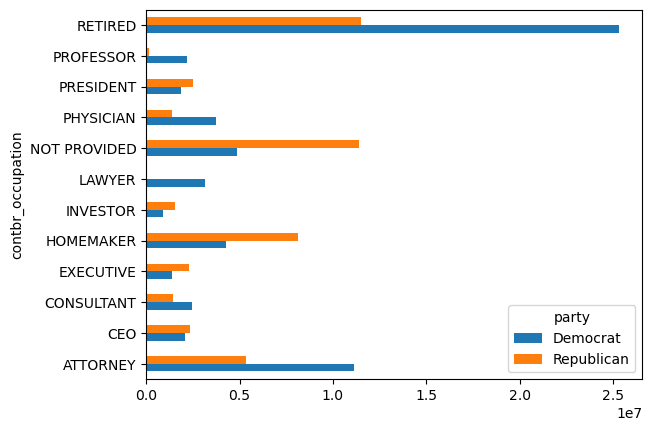

In [36]:
over_2mm.plot(kind='barh')

In [ ]:
#top company or occupation that donoted to each candidate
def get_top_amounts(group, key, n=5):
    totals = group.groupby(key)['contb_receipt_amt'].sum()
    return totals.nlargest(n)

